In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

Saving PRCP-1016-HeartDieseasePred.zip to PRCP-1016-HeartDieseasePred.zip


In [5]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("heart_disease_data")

print("ZIP extracted successfully!")
print(os.listdir("heart_disease_data"))

ZIP extracted successfully!
['Data']


In [7]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders available:")
for root, dirs, files in os.walk("/content"):
    for file in files:
        print(os.path.join(root, file))

Current directory:
/content

Files/folders available:
/content/PRCP-1016-HeartDieseasePred.zip
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/active_config
/content/.config/.last_survey_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/gce
/content/.config/default_configs.db
/content/.config/.last_update_check.json
/content/.config/logs/2026.09.04/13.32.37.832911.log
/content/.config/logs/2026.09.04/13.32.27.247672.log
/content/.config/logs/2026.09.04/13.32.28.853654.log
/content/.config/logs/2026.09.04/13.31.54.252184.log
/content/.config/logs/2026.09.04/13.32.37.014185.log
/content/.config/logs/2026.09.04/13.32.19.320548.log
/content/.config/configurations/config_default
/content/heart_disease_data/Data/values.csv
/content/heart_disease_data/Data/labels.csv
/content/heart_disease_data/Data/description.docx
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/s

In [8]:
import os
import zipfile
import pandas as pd

# Find uploaded ZIP files
zip_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".zip"):
            zip_files.append(os.path.join(root, file))

print("ZIP files found:")
for f in zip_files:
    print(f)

# Extract the first ZIP
if zip_files:
    zip_path = zip_files[0]

    extract_path = "/content/heart_data"

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)

    print("\nZIP extracted successfully!")

# Find CSV files anywhere inside extracted folder
csv_files = []

for root, dirs, files in os.walk("/content/heart_data"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("\nCSV files found:")
for f in csv_files:
    print(f)

ZIP files found:
/content/PRCP-1016-HeartDieseasePred.zip

ZIP extracted successfully!

CSV files found:
/content/heart_data/Data/values.csv
/content/heart_data/Data/labels.csv


In [2]:
import os

print(os.listdir())

['.config', 'sample_data']


In [3]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/sample_data/california_housing_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv


In [4]:
import pandas as pd

values = pd.read_csv("/content/heart_disease_data/values.csv")
labels = pd.read_csv("/content/heart_disease_data/labels.csv")

print("Values shape:", values.shape)
print("Labels shape:", labels.shape)

display(values.head())
display(labels.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/heart_disease_data/values.csv'

In [6]:
from google.colab import files

uploaded = files.upload()


Saving labels.csv to labels (1).csv
Saving values.csv to values.csv


In [7]:
import os

print(os.listdir("/content"))

['.config', 'values.csv', 'labels (1).csv', 'labels.csv', 'sample_data']


In [8]:
import pandas as pd

values = pd.read_csv("/content/values.csv")
labels = pd.read_csv("/content/labels.csv")

print("Values shape:", values.shape)
print("Labels shape:", labels.shape)

display(values.head())
display(labels.head())

Values shape: (180, 14)
Labels shape: (180, 2)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [35]:
import pandas as pd

values = pd.read_csv("/content/values.csv")
labels = pd.read_csv("/content/labels.csv")

print(" Dataset loaded successfully")
print("Values shape:", values.shape)
print("Labels shape:", labels.shape)

print("\n--- Values Info ---")
values.info()

print("\n--- Labels Info ---")
labels.info()

print("\n--- Missing Values ---")
print(values.isnull().sum())

print("\n--- First 5 Records ---")
display(values.head())

 Dataset loaded successfully
Values shape: (180, 14)
Labels shape: (180, 2)

--- Values Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    fl

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [10]:
print("Labels columns:")
print(labels.columns.tolist())

print("\nLabel distribution:")
print(labels.iloc[:, 0].value_counts())

Labels columns:
['patient_id', 'heart_disease_present']

Label distribution:
patient_id
0z64un    1
ryoo3j    1
yt1s1x    1
l2xjde    1
oyt4ek    1
         ..
5qfar3    1
2s2b1f    1
nsd00i    1
0xw93k    1
2nx10r    1
Name: count, Length: 180, dtype: int64


In [11]:
data = values.copy()

data["target"] = labels.iloc[:, 0].values

print("Final dataset shape:", data.shape)

display(data.head())

Final dataset shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,target
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0z64un
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,ryoo3j
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,yt1s1x
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,l2xjde
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,oyt4ek


In [12]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

Dataset Shape: (180, 15)

Column Names:
['patient_id', 'slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina', 'target']

Data Types:
patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int

target
0z64un    1
ryoo3j    1
yt1s1x    1
l2xjde    1
oyt4ek    1
         ..
5qfar3    1
2s2b1f    1
nsd00i    1
0xw93k    1
2nx10r    1
Name: count, Length: 180, dtype: int64


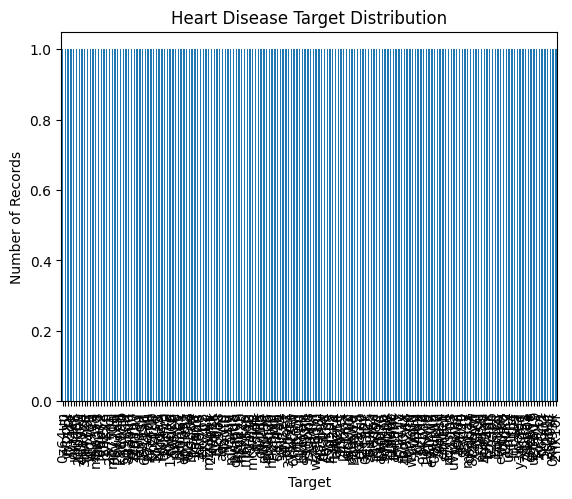

In [13]:
import matplotlib.pyplot as plt

print(data["target"].value_counts())

data["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Records")
plt.show()

In [14]:
display(data.describe())

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000


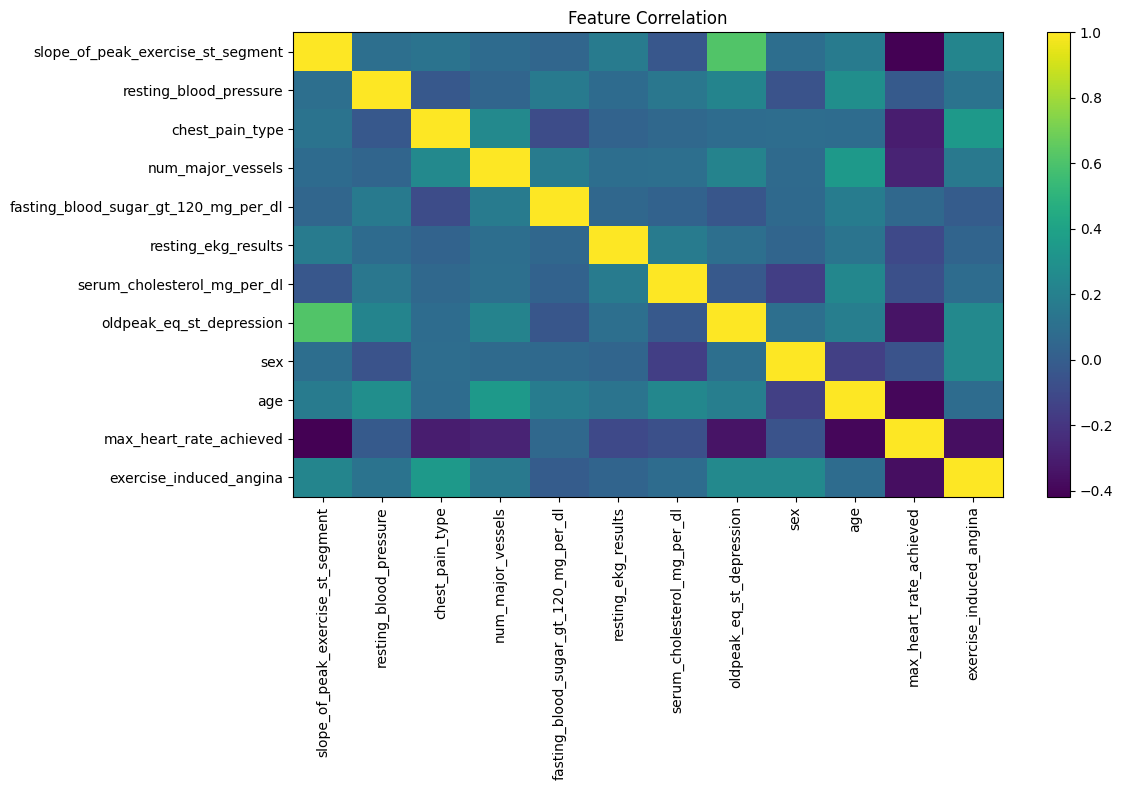

In [15]:
import matplotlib.pyplot as plt

corr = data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

In [16]:
X = data.drop("target", axis=1)
y = data["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (180, 14)
y shape: (180,)


In [18]:
print(y.value_counts(dropna=False))

target
0z64un    1
ryoo3j    1
yt1s1x    1
l2xjde    1
oyt4ek    1
         ..
5qfar3    1
2s2b1f    1
nsd00i    1
0xw93k    1
2nx10r    1
Name: count, Length: 180, dtype: int64


In [19]:
print("Unique target values:")
print(y.unique())

print("Number of unique classes:", y.nunique())

Unique target values:
['0z64un' 'ryoo3j' 'yt1s1x' 'l2xjde' 'oyt4ek' 'ldukkw' '2gbyh9' 'daa9kp'
 '3nwy2n' '1r508r' 'ldg4b9' 'xc17yq' 'mpggsq' 'zlyac8' 'f06u72' '2fv3rc'
 'qyrkxn' '237mql' 'mc750a' '30v796' 'cvux3j' 'k8899q' 'jhdvtb' '5g9v0h'
 '83asqd' 'gla0im' 'zzmfh7' 'f4g1ay' 'lek9q9' '8265rl' '6017a1' 'z7xkou'
 'k7ef7h' '0n5fu0' '55xksg' 'pjgqa3' 'xkdz7j' 'tpuevg' 'ascl42' '1xwoe6'
 'ty4ik8' 'gx6yxl' 'hlmts5' 'yx0q6k' 'ep1o51' 'gj1e5z' '6219kl' 'rp9g6x'
 '1aeaff' 'y3prof' '3drd48' 'ejo7p3' 'r7y4i1' 'mznwxv' '27oevk' 'jwqi3k'
 '328lkl' 'tlk9o8' 'aq2vrq' 'ilogfb' 'rv6siv' 'm2a4i9' 'pwigd8' 'qwapdq'
 '4sd1xn' 'nck22c' 'm6zksp' 'f70grj' 'k1art8' 'mcwqgs' '3jsjqk' 'ik7hfs'
 'qwj1yf' 'qvhk9e' 'igwnqo' '4v0q7o' 'hh2awp' 'vfjppl' '6lu42b' 'shiro4'
 '3wl3z4' 'ebioez' '37c0vm' 'v52zcs' '6nkcaw' 'hfp05i' 'grfxwd' 'bvcxah'
 'i49srr' '93dbhq' 'jscmp8' 'zaytyf' 'wze8qm' 'w3933i' '7uch9x' 'dy5hxt'
 'c0gkqc' 'z5g5p3' 'h3uzv8' 'bthqr4' 'rfj25e' '9f92et' '24fopx' 'ldr1mz'
 'wokyol' 'p5orwa' 's8dx1q' '

In [20]:
print(y.dtype)
print(y.head(20))

object
0     0z64un
1     ryoo3j
2     yt1s1x
3     l2xjde
4     oyt4ek
5     ldukkw
6     2gbyh9
7     daa9kp
8     3nwy2n
9     1r508r
10    ldg4b9
11    xc17yq
12    mpggsq
13    zlyac8
14    f06u72
15    2fv3rc
16    qyrkxn
17    237mql
18    mc750a
19    30v796
Name: target, dtype: object


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (144, 14)
Testing data: (36, 14)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(" Train/Test split completed")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

 Train/Test split completed
X_train: (144, 14)
X_test : (36, 14)
y_train: (144,)
y_test : (36,)


In [24]:
print("Column data types:\n")
print(X.dtypes)

print("\nText/Object columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Column data types:

patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
dtype: object

Text/Object columns:
['patient_id', 'thal']


In [25]:
text_cols = X.select_dtypes(include=["object"]).columns

for col in text_cols:
    print(f"\n--- {col} ---")
    print(X[col].head(10).tolist())


--- patient_id ---
['0z64un', 'ryoo3j', 'yt1s1x', 'l2xjde', 'oyt4ek', 'ldukkw', '2gbyh9', 'daa9kp', '3nwy2n', '1r508r']

--- thal ---
['normal', 'normal', 'normal', 'reversible_defect', 'reversible_defect', 'normal', 'reversible_defect', 'fixed_defect', 'reversible_defect', 'normal']


In [26]:
text_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Removing text columns:", text_cols)

X_numeric = X.drop(columns=text_cols)

print("\nRemaining columns:")
print(X_numeric.columns.tolist())

Removing text columns: ['patient_id', 'thal']

Remaining columns:
['slope_of_peak_exercise_st_segment', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina']


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (144, 12)
X_test : (36, 12)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Scaling completed successfully")

 Scaling completed successfully


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print(" Logistic Regression model trained successfully")

 Logistic Regression model trained successfully


In [32]:
y_pred = model.predict(X_test_scaled)

print(" Prediction completed")
print("Predictions:", y_pred)

 Prediction completed
Predictions: ['yx0q6k' 'ascl42' 'qcjf51' 'v52zcs' '2nx10r' 'l0c19s' 'fz84ac' '9f92et'
 'ty4ik8' '3drd48' 'e3dnw3' 'a946ij' 'ebioez' 'aq2vrq' '93dbhq' 'hh2awp'
 'f70grj' '27oevk' 'shiro4' 'tlk9o8' '7zbya5' '7zbya5' 'nfag5b' 'lek9q9'
 'ryoo3j' 'nfag5b' 'yx0q6k' 'srm6ut' 'ik7hfs' '237mql' 'f70grj' 'y3m2bd'
 'syvayq' '98kb5h' 'tbo0wx' 'ik7hfs']


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


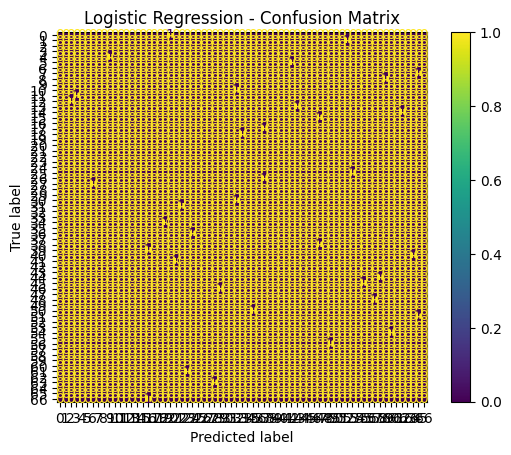

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

      0ryxtv       0.00      0.00      0.00       1.0
      1r508r       0.00      0.00      0.00       1.0
      237mql       0.00      0.00      0.00       0.0
      27oevk       0.00      0.00      0.00       0.0
      2fqzg8       0.00      0.00      0.00       1.0
      2fv3rc       0.00      0.00      0.00       1.0
      2nx10r       0.00      0.00      0.00       0.0
      30v796       0.00      0.00      0.00       1.0
      328lkl       0.00      0.00      0.00       1.0
      3drd48       0.00      0.00      0.00       0.0
      3ze7pv       0.00      0.00      0.00       1.0
      4b32pd       0.00      0.00      0.00       1.0
      5o32oi       0.00      0.00      0.00       1.0
      6017a1       0.00      0.00      0.00       1.0
      6lu42b       0.00      0.00      0.00       1.0
      7eyvsi       0.00      0.00      0.00       1.0
      7zbya5       0.00      0.00      0.00       0.0
      8265rl       0.00    

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Remove target
X = data.drop("target", axis=1)
y = data["target"]

# Keep only numerical columns
X_numeric = X.select_dtypes(include=["number"])

print("Original columns:", X.shape[1])
print("Numerical columns:", X_numeric.shape[1])

print("\nRemoved non-numeric columns:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.20,
    random_state=42
)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

Original columns: 14
Numerical columns: 12

Removed non-numeric columns:
['patient_id', 'thal']

X_train: (144, 12)
X_test : (36, 12)


In [42]:
print("Text columns in X_train:")
print(X_train.select_dtypes(exclude=["number"]).columns.tolist())

print("\nData types:")
print(X_train.dtypes)

Text columns in X_train:
[]

Data types:
slope_of_peak_exercise_st_segment         int64
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
dtype: object


In [43]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(
    y_test, dt_pred,
    average="weighted",
    zero_division=0
)
dt_recall = recall_score(
    y_test, dt_pred,
    average="weighted",
    zero_division=0
)
dt_f1 = f1_score(
    y_test, dt_pred,
    average="weighted",
    zero_division=0
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred,
    zero_division=0
))

Decision Tree Results
---------------------
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

      08usun       0.00      0.00      0.00       0.0
      0g192k       0.00      0.00      0.00       0.0
      0n5fu0       0.00      0.00      0.00       0.0
      0ryxtv       0.00      0.00      0.00       1.0
      0z64un       0.00      0.00      0.00       0.0
      1r508r       0.00      0.00      0.00       1.0
      2fqzg8       0.00      0.00      0.00       1.0
      2fv3rc       0.00      0.00      0.00       1.0
      2gbyh9       0.00      0.00      0.00       0.0
      30v796       0.00      0.00      0.00       1.0
      328lkl       0.00      0.00      0.00       1.0
      3wl3z4       0.00      0.00      0.00       0.0
      3ze7pv       0.00      0.00      0.00       1.0
      4b32pd       0.00      0.00      0.00       1.0
      5o32oi       0.00      0.00      0.00       1.0
      6

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully")

Random Forest trained successfully


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    zero_division=0
))

Random Forest Results
---------------------
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

      0ryxtv       0.00      0.00      0.00       1.0
      1r508r       0.00      0.00      0.00       1.0
      1wwvr0       0.00      0.00      0.00       0.0
      2fqzg8       0.00      0.00      0.00       1.0
      2fv3rc       0.00      0.00      0.00       1.0
      30v796       0.00      0.00      0.00       1.0
      328lkl       0.00      0.00      0.00       1.0
      3drd48       0.00      0.00      0.00       0.0
      3jsjqk       0.00      0.00      0.00       0.0
      3ze7pv       0.00      0.00      0.00       1.0
      4b32pd       0.00      0.00      0.00       1.0
      5o32oi       0.00      0.00      0.00       1.0
      6017a1       0.00      0.00      0.00       1.0
      6lu42b       0.00      0.00      0.00       1.0
      7eyvsi       0.00      0.00      0.00       1.0
      8

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
6,serum_cholesterol_mg_per_dl,0.154931
9,age,0.144992
10,max_heart_rate_achieved,0.143294
1,resting_blood_pressure,0.138752
7,oldpeak_eq_st_depression,0.107812
2,chest_pain_type,0.068794
3,num_major_vessels,0.054903
0,slope_of_peak_exercise_st_segment,0.049813
5,resting_ekg_results,0.041160
8,sex,0.036135


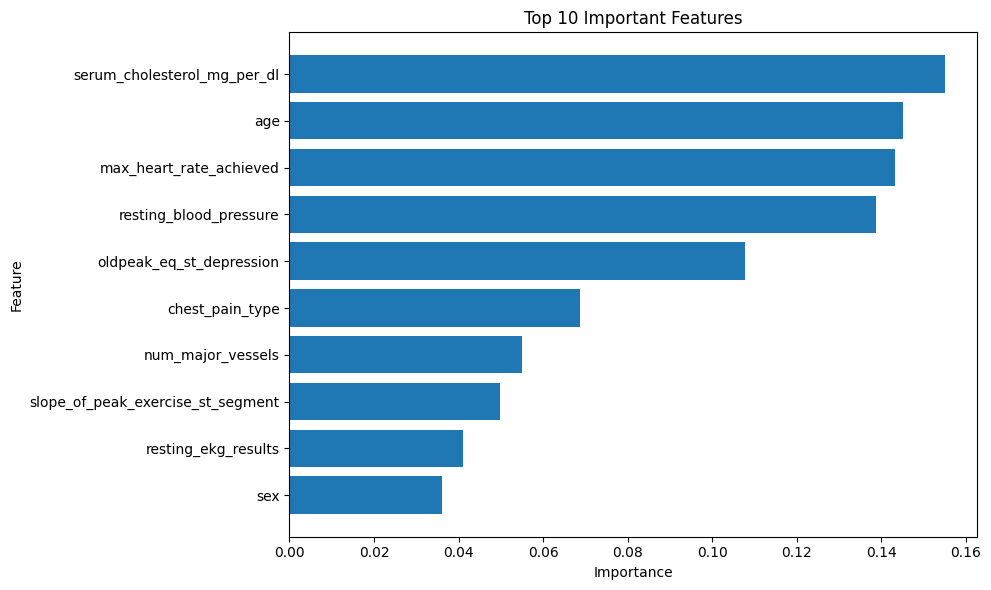

In [48]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [49]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.0,0.0,0.0,0.0
1,Decision Tree,0.0,0.0,0.0,0.0
2,Random Forest,0.0,0.0,0.0,0.0


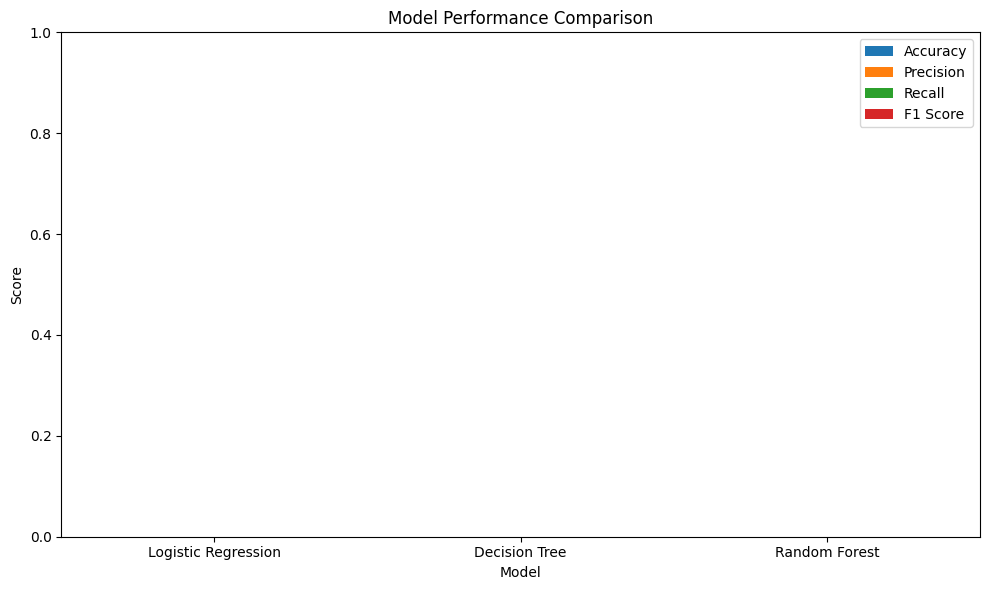

In [50]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Random Forest Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


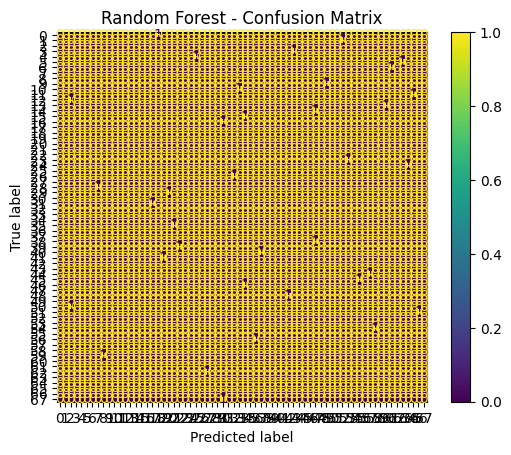

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [52]:
import joblib

joblib.dump(rf_model, "/content/heart_disease_model.pkl")
joblib.dump(X_train.columns.tolist(), "/content/feature_columns.pkl")

print("Model saved successfully")
print("heart_disease_model.pkl")
print("feature_columns.pkl")

Model saved successfully
heart_disease_model.pkl
feature_columns.pkl


In [53]:
from google.colab import files

files.download("/content/heart_disease_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
files.download("/content/feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>